### Imports

In [14]:
from src.data import DataPreparator, CachedCollection, LazyLoadCollection, PKSampler
from src.distances.index import BinaryStrategy, SparseIndex, DenseIndex
from src.distances.kernels import BinaryJaccardKernel, BhattacharyyaKernel, EuclidianDistanceKernel
from src.distances.fusion import RRFBasedFusion
from src.rerankers import ORBReranker, HSVReranker
from src.extractors import DocTRTextExtractor, HSVExtractor, OrbFeatureExtractor, SiameseDino
from src.core.engine import SearchEngine
from src.feature_stores import InMemoryStore
from src.eval import Recall
from src.preprocess import PolarTransform, YOLOCustomCrop
from src.types import RetrievalChannel

In [27]:
import torch
from torch.utils.data import DataLoader
from torchvision.transforms import v2
from pathlib import Path
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import math

### Functions

In [25]:


def show_images(paths: list[str] | list[Image.Image], cols: int = 3, figsize_per_image: tuple = (4, 4)) -> None:
    """
    Affiche une liste d'images sur une figure matplotlib.

    Args:
        paths: Liste des chemins vers les images ou objets PIL Image.
        cols: Nombre de colonnes dans la grille (défaut: 3).
        figsize_per_image: Taille (largeur, hauteur) par image en pouces.
    """
    n = len(paths)
    if n == 0:
        print("Aucune image à afficher.")
        return

    rows = math.ceil(n / cols)
    fig, axes = plt.subplots(
        rows, cols,
        figsize=(figsize_per_image[0] * cols, figsize_per_image[1] * rows)
    )

    # Normalise axes en tableau 1D
    axes = [axes] if n == 1 else list(axes.flat)

    for ax, path in zip(axes, paths):
        try:
            if isinstance(path, Image.Image):
                img = path
                title = getattr(path, "filename", None)
                title = title.split("/")[-1] if title else "PIL Image"
            else:
                img = Image.open(path)
                title = path.split("/")[-1]

            ax.imshow(img)
            ax.set_title(title, fontsize=9)
        except Exception as e:
            ax.text(0.5, 0.5, f"Erreur:\n{e}", ha="center", va="center", color="red")
        ax.axis("off")

    # Cache les axes inutilisés si la grille n'est pas pleine
    for ax in axes[n:]:
        ax.set_visible(False)

    plt.tight_layout()
    plt.show()

### Corps

In [3]:
AUGMENTED_DATA_PATH = Path("/Users/timothee/Documents/programming/DIHT/data/cropped_data")
ORIGINAL_DATA_PATH = Path("/Users/timothee/Documents/programming/DIHT/data/cropped_data")

In [4]:
dp = DataPreparator(ORIGINAL_DATA_PATH, AUGMENTED_DATA_PATH)

Found 102 total classes.


In [5]:
train_ratio = 0.7
val_ratio = 0.3
max_gallery_instances = 1
n_query = 1

k_fold_splits = dp.get_k_folds(4, max_gallery_instances, n_query)

================ PROCESSING SPLIT 0 ================
Processing Train classes...
Processing Validation classes...
Processing Test classes...

--- Data Split Summary ---
Training Loader:     308 samples from 77 classes (Augmented)
Gallery Loader:      102 samples from 102 classes (Original)
Val Query Loader:     25 samples from 25 classes (Original)
Test Query Loader:     0 samples from 0 classes (Original)


================ PROCESSING SPLIT 1 ================
Processing Train classes...
Processing Validation classes...
Processing Test classes...

--- Data Split Summary ---
Training Loader:     304 samples from 76 classes (Augmented)
Gallery Loader:      102 samples from 102 classes (Original)
Val Query Loader:     26 samples from 26 classes (Original)
Test Query Loader:     0 samples from 0 classes (Original)


================ PROCESSING SPLIT 2 ================
Processing Train classes...
Processing Validation classes...
Processing Test classes...

--- Data Split Summary ---
Trainin

In [10]:
train_ratio = 0.7
val_ratio = 0.25
max_gallery_instances = 1
n_query = 1

splits = dp.train_val_test_split(train_ratio, val_ratio, max_gallery_instances, n_query)

Processing Train classes...
Processing Validation classes...
Processing Test classes...

--- Data Split Summary ---
Training Loader:     284 samples from 71 classes (Augmented)
Gallery Loader:      102 samples from 102 classes (Original)
Val Query Loader:     25 samples from 25 classes (Original)
Test Query Loader:     6 samples from 6 classes (Original)


In [11]:
train_paths, train_labels = splits["train"]
gallery_paths, gallery_labels = splits["gallery"]
query_paths, query_labels = splits["val_query"]

In [12]:
def labelset(paths) -> set:
    s = set()
    for path in paths:
        label = path.split('/')[-2]
        s.add(label)

    return s

print(labelset(gallery_paths).intersection(labelset(query_paths)))

{'075', '076', '003', '038', '089', '097', '030', '002', '088', '022', '094', '100', '049', '053', '064', '024', '087', '059', '082', '033', '083', '058', '042', '060', '095'}


In [6]:
#crop = YOLOCustomCrop("runs/segment/train-3/weights/best.pt")
polar = PolarTransform()
resize = v2.Resize((640, 640))
preprocessor = v2.Compose([resize])

In [7]:
train_transforms = v2.Compose([                           
        #v2.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1, hue=0), 
        v2.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 0.9)),
        v2.RandomRotation(degrees=180),
    ])

In [26]:
cutoff = 1000
gallery_dataset = CachedCollection(gallery_paths[:cutoff],
                                   gallery_labels[:cutoff],
                                   preprocessor=preprocessor)
query_dataset = CachedCollection(query_paths[:cutoff],
                                 query_labels[:cutoff],
                                 preprocessor=preprocessor)
train_dataset = CachedCollection(train_paths[:cutoff],
                                 train_labels[:cutoff],
                                 preprocessor=preprocessor,
                                 transform=train_transforms)

In [ ]:
from src.config import load_config

cfg = load_config("../config/config.yaml")

print(cfg.train.epochs)
print(cfg.model.backbone_name)
print(cfg.base.device)

10
facebook/dinov3-vits16-pretrain-lvd1689m
gpu


In [9]:
def numpy_collate(batch):
    elem = batch[0]
    if isinstance(elem, np.ndarray):
        return np.stack(batch)
    elif isinstance(elem, dict):
        return {k: numpy_collate([d[k] for d in batch]) for k in elem}
    elif isinstance(elem, (tuple, list)):
        return type(elem)(numpy_collate(s) for s in zip(*batch))
    else:
        return batch  # fallback: plain list

In [10]:
pk_sampler = PKSampler(train_dataset, cfg.train.sampler_P, cfg.train.sampler_K)

gallery_dataloader = DataLoader(gallery_dataset, batch_size=32, collate_fn=numpy_collate)
query_dataloader = DataLoader(query_dataset, batch_size=32, collate_fn=numpy_collate)
train_dataloader = DataLoader(train_dataset, batch_sampler=pk_sampler, collate_fn=numpy_collate)

NameError: name 'train_dataset' is not defined

In [ ]:
fs = InMemoryStore()


bs = BinaryStrategy()
bin_kernel = BinaryJaccardKernel()
tcsr = SparseIndex(bin_kernel, bs)
#ocr = DocTRTextExtractor()
#channel1 = RetrievalChannel(ocr, tcsr, bin_kernel)

bhatt_kernel = BhattacharyyaKernel()
di_hsv = DenseIndex(bhatt_kernel)
hsv = HSVExtractor()
channel2 = RetrievalChannel(hsv, di_hsv, bhatt_kernel)

euclidian_kernel = EuclidianDistanceKernel()
di_sd = DenseIndex(euclidian_kernel)
siamese_model = SiameseDino(cfg)

for param in siamese_model._backbone.parameters():
    param.requires_grad = False
for param in siamese_model._backbone.layer[-2:].parameters():
    param.requires_grad = True
    
optim_params = [
    {"params": siamese_model.projection_head.parameters(), "lr": cfg.train.head_lr},
    {"params": siamese_model._backbone.layer[-2:].parameters(), "lr": cfg.train.backbone_lr}
]

optimizer = torch.optim.Adam(optim_params, weight_decay=cfg.train.weight_decay)
siamese_model.set_optimizer(optimizer)
channel3 = RetrievalChannel(siamese_model, di_sd, euclidian_kernel, is_trainable=True)


fusion = RRFBasedFusion()
channels = [channel3]

orb = OrbFeatureExtractor(500)
reranker = ORBReranker(orb)
hsv_reranker = HSVReranker()
top_k = 10

fbe = SearchEngine(preprocessor, channels, fs, fusion)
#fbe = SearchEngine(preprocessor, channels, fs, fusion, reranker=reranker, top_k_candidates=top_k)

Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

wandb: Currently logged in as: entropeaks (entropeaks-universit-paul-sabatier-toulouse-iii) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [ ]:
metric = Recall(recall_k=[1, 5, 10])
fbe.fit(train_dataloader)
fbe.evaluate(gallery_dataloader, query_dataloader, metric)

--------------- Training Siamese model ---------------


 10%|█         | 1/10 [00:23<03:34, 23.79s/it]

Epoch 1: {'loss': 0.148991160094738, 'positive_dist': 0.4216821491718292, 'negative_dist': 0.5726910382509232, 'triplets_mined': 338460}


 20%|██        | 2/10 [00:46<03:03, 22.99s/it]

Epoch 2: {'loss': 0.12216264568269253, 'positive_dist': 0.8251333832740784, 'negative_dist': 1.0029707103967667, 'triplets_mined': 152481}


...

Computing features blocks: 100%|██████████| 1/1 [00:03<00:00,  3.40s/it]


✅ Gallery prepared: 102 images
Computing queries features...


Computing features blocks: 100%|██████████| 1/1 [00:00<00:00,  1.26it/s]


Feature 0: min=0.3094, max=1.7054, std=0.1945, mean=1.2679
Feature 0 after norm: min=61.0000, max=162.0000, std=29.4492, mean=111.5000
[[        124         119         123 ...          66         148          63]
 [         91         140         135 ...          96         147         110]
 [        142         101          63 ...         115         157          99]
 ...
 [        132          85          91 ...         127         156         115]
 [        104          65         143 ...          93         161          87]
 [        147          88          78 ...         148         107         135]]
Scores before reranking:
{'recall@1': 0.68, 'recall@5': 0.84, 'recall@10': 0.96}
Scores after reranking:
{'recall@1': 0.6, 'recall@5': 0.92, 'recall@10': 0.96}
Elapsed time for evaluate = 5.39s
Energy consumption for evaluate = 0.000019 kWh
Carbon footprint for evaluate = 0.000001 g.eq.CO2


{'recall@1': 0.6, 'recall@5': 0.92, 'recall@10': 0.96}

In [40]:
for fold in k_fold_splits:
    print(len(labelset(fold["gallery"][0]).intersection(labelset(fold["val_query"][0]))))
    break

25


In [ ]:
def test_one_fold(fold):
    
    return score

In [ ]:
metric = Recall([1, 3, 5])
cutoff = 1000

results = []
for fold in k_fold_splits:
    train_paths, train_labels = fold["train"]
    gallery_paths, gallery_labels = fold["gallery"]
    query_paths, query_labels = fold["val_query"]

    fs = InMemoryStore()
    euclidian_kernel = EuclidianDistanceKernel()
    di_sd = DenseIndex(euclidian_kernel)
    siamese_model = SiameseDino(cfg)
    
    for param in siamese_model._backbone.parameters():
        param.requires_grad = False
    for param in siamese_model._backbone.layer[-2:].parameters():
        param.requires_grad = True
        
    optim_params = [
        {"params": siamese_model.projection_head.parameters(), "lr": cfg.train.head_lr},
        {"params": siamese_model._backbone.layer[-2:].parameters(), "lr": cfg.train.backbone_lr}
    ]
    
    optimizer = torch.optim.Adam(optim_params, weight_decay=cfg.train.weight_decay)
    siamese_model.set_optimizer(optimizer)
    channel3 = RetrievalChannel(siamese_model, di_sd, euclidian_kernel, is_trainable=True)
    fbe = SearchEngine(preprocessor, [channel3], fs, RRFBasedFusion())

    gallery_dataset = CachedCollection(gallery_paths[:cutoff],
                                    gallery_labels[:cutoff],
                                    preprocessor=preprocessor)
    query_dataset = CachedCollection(query_paths[:cutoff],
                                    query_labels[:cutoff],
                                    preprocessor=preprocessor)
    train_dataset = CachedCollection(train_paths[:cutoff],
                                    train_labels[:cutoff],
                                    preprocessor=preprocessor,
                                    transform=train_transforms)

    pk_sampler = PKSampler(train_dataset, cfg.train.sampler_P, cfg.train.sampler_K)

    gallery_dataloader = DataLoader(gallery_dataset, batch_size=32, collate_fn=numpy_collate)
    query_dataloader = DataLoader(query_dataset, batch_size=32, collate_fn=numpy_collate)
    train_dataloader = DataLoader(train_dataset, batch_sampler=pk_sampler, collate_fn=numpy_collate)

    fbe.fit(train_dataloader)
    score = fbe.evaluate(gallery_dataloader, query_dataloader, metric)

    print(score)
    results.append(score)


Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


--------------- Training Siamese model ---------------


 10%|█         | 1/10 [00:23<03:35, 23.92s/it]

Epoch 1: {'loss': 0.13865838572382927, 'positive_dist': 0.4946715906262398, 'negative_dist': 0.6560132130980492, 'triplets_mined': 286833}


...

🔨 Preparing gallery (computing features)...


Computing features blocks: 100%|██████████| 1/1 [00:05<00:00,  5.30s/it]


✅ Gallery prepared: 102 images
Computing queries features...


Computing features blocks: 100%|██████████| 1/1 [00:01<00:00,  1.42s/it]

Feature 0: min=0.4017, max=1.7558, std=0.2003, mean=1.2804
Feature 0 after norm: min=61.0000, max=162.0000, std=29.4490, mean=111.5000
[[         84         132         113 ...          89         135         115]
 [        111         130         125 ...          68          63          87]
 [        125         118         131 ...         139          81         112]
 ...
 [        106         110         144 ...          61          93          84]
 [        128          87         115 ...         108          61         149]
 [         72          99         128 ...          68          88          61]]
Elapsed time for evaluate = 6.73s
Energy consumption for evaluate = 0.000038 kWh
Carbon footprint for evaluate = 0.000002 g.eq.CO2
{'recall@1': 0.8846153846153846, 'recall@3': 0.9615384615384616, 'recall@5': 0.9615384615384616}


In [24]:
import pandas as pd

pd.DataFrame(results)

,recall@1,recall@3,recall@5
0,0.880000,0.960000,1.000000
1,0.692308,0.961538,1.000000
2,0.880000,0.920000,1.000000
3,0.884615,0.961538,0.961538


In [35]:
fold = k_fold_splits[1]
train_paths, train_labels = fold["train"]
gallery_paths, gallery_labels = fold["gallery"]
query_paths, query_labels = fold["val_query"]

fs = InMemoryStore()
euclidian_kernel = EuclidianDistanceKernel()
di_sd = DenseIndex(euclidian_kernel)
siamese_model = SiameseDino(cfg)

for param in siamese_model._backbone.parameters():
    param.requires_grad = False
for param in siamese_model._backbone.layer[-2:].parameters():
    param.requires_grad = True
    
optim_params = [
    {"params": siamese_model.projection_head.parameters(), "lr": cfg.train.head_lr},
    {"params": siamese_model._backbone.layer[-2:].parameters(), "lr": cfg.train.backbone_lr}
]

optimizer = torch.optim.Adam(optim_params, weight_decay=cfg.train.weight_decay)
siamese_model.set_optimizer(optimizer)
channel3 = RetrievalChannel(siamese_model, di_sd, euclidian_kernel, is_trainable=True)
fbe = SearchEngine(preprocessor, [channel3], fs, RRFBasedFusion())

gallery_dataset = CachedCollection(gallery_paths[:cutoff],
                                gallery_labels[:cutoff],
                                preprocessor=preprocessor)
query_dataset = CachedCollection(query_paths[:cutoff],
                                query_labels[:cutoff],
                                preprocessor=preprocessor)
train_dataset = CachedCollection(train_paths[:cutoff],
                                train_labels[:cutoff],
                                preprocessor=preprocessor,
                                transform=train_transforms)

pk_sampler = PKSampler(train_dataset, cfg.train.sampler_P, cfg.train.sampler_K)

gallery_dataloader = DataLoader(gallery_dataset, batch_size=32, collate_fn=numpy_collate)
query_dataloader = DataLoader(query_dataset, batch_size=32, collate_fn=numpy_collate)
train_dataloader = DataLoader(train_dataset, batch_sampler=pk_sampler, collate_fn=numpy_collate)

fbe.fit(train_dataloader)
score = fbe.evaluate(gallery_dataloader, query_dataloader, metric)

Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


--------------- Training Siamese model ---------------


 10%|█         | 1/10 [00:24<03:36, 24.02s/it]

Epoch 1: {'loss': 0.14271656796336174, 'positive_dist': 0.38866831362247467, 'negative_dist': 0.545951783657074, 'triplets_mined': 321502}


...

🔨 Preparing gallery (computing features)...


Computing features blocks: 100%|██████████| 1/1 [00:05<00:00,  5.66s/it]


✅ Gallery prepared: 102 images
Computing queries features...


Computing features blocks: 100%|██████████| 1/1 [00:01<00:00,  1.36s/it]

Feature 0: min=0.3654, max=1.8019, std=0.2011, mean=1.2710
Feature 0 after norm: min=61.0000, max=162.0000, std=29.4490, mean=111.5000
[[         85         108         106 ...          67         121         139]
 [        101         118         145 ...         124         148         156]
 [        140          93         158 ...         108         144         134]
 ...
 [         62          75         115 ...          61          78         150]
 [        148         144         106 ...         130          65          67]
 [        137         106         102 ...         116          72          62]]
Elapsed time for evaluate = 7.05s
Energy consumption for evaluate = 0.000038 kWh
Carbon footprint for evaluate = 0.000002 g.eq.CO2


In [ ]:
fbe._channels[0].extractor._fit_one_epoch(train_dataloader)

ZeroDivisionError: float division by zero

**Identifying misclassified pictures**

In [37]:
query_labels = torch.tensor(query_dataloader.dataset.labels)
gallery_labels = torch.tensor(gallery_dataloader.dataset.labels)

query_paths = query_dataloader.dataset.images_paths
gallery_paths = gallery_dataloader.dataset.images_paths

print("Computing queries features...")
query_features = fbe._compute_features(query_dataloader, update_index=False)

dists = fbe._compute_distances(query_features)

k = 1

topk_indices = torch.from_numpy(dists).topk(k, largest=False).indices

l = []

for i, q_label in enumerate(query_labels):
    gallery_indices = topk_indices[i, :k]
    retrieved_labels = gallery_labels[gallery_indices]
    max_gallery_idx = gallery_indices[0]
    if q_label not in retrieved_labels:
        l.append((query_paths[i], gallery_paths[max_gallery_idx]))

Computing queries features...


Computing features blocks: 100%|██████████| 1/1 [00:00<00:00,  1.12it/s]

Feature 0: min=0.3772, max=1.7993, std=0.2016, mean=1.2706
Feature 0 after norm: min=61.0000, max=162.0000, std=29.4490, mean=111.5000
[[         86         109         107 ...          69         122         141]
 [         99         119         145 ...         116         148         156]
 [        139          93         158 ...         108         143         136]
 ...
 [         62          73         117 ...          61          77         151]
 [        149         145         106 ...         130          65          67]
 [        137         107         103 ...         117          72          62]]


In [38]:
len(l)

6

In [40]:
l

[('/Users/timothee/Documents/programming/DIHT/data/cropped_data/092/02.jpg',
  '/Users/timothee/Documents/programming/DIHT/data/cropped_data/101/02.jpg'),
 ('/Users/timothee/Documents/programming/DIHT/data/cropped_data/084/01.jpg',
  '/Users/timothee/Documents/programming/DIHT/data/cropped_data/008/02.jpg'),
 ('/Users/timothee/Documents/programming/DIHT/data/cropped_data/079/02.jpg',
  '/Users/timothee/Documents/programming/DIHT/data/cropped_data/061/02.jpg'),
 ('/Users/timothee/Documents/programming/DIHT/data/cropped_data/008/01.jpg',
  '/Users/timothee/Documents/programming/DIHT/data/cropped_data/084/02.jpg'),
 ('/Users/timothee/Documents/programming/DIHT/data/cropped_data/074/02.jpg',
  '/Users/timothee/Documents/programming/DIHT/data/cropped_data/101/02.jpg'),
 ('/Users/timothee/Documents/programming/DIHT/data/cropped_data/099/01.jpg',
  '/Users/timothee/Documents/programming/DIHT/data/cropped_data/098/03.jpg')]

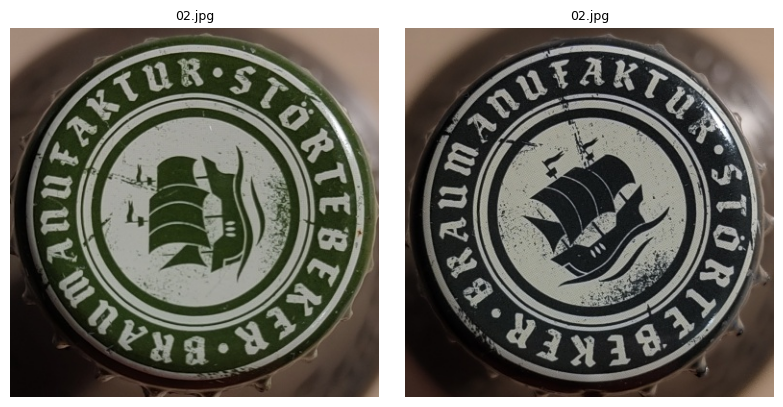

In [47]:
show_images(l[0])

In [91]:
from transformers.image_utils import load_image

path = "/Users/timothee/Documents/programming/DIHT/data/test_data/IMG_2939.jpg"
img = load_image(path)
img = preprocessor(img)
img = np.array(img)

query_features = fbe._compute_features([[[img], []]], update_index=True)
fs.add(path, query_features[0])

Computing features blocks: 100%|██████████| 1/1 [00:00<00:00, 20.86it/s]


Computing features blocks: 100%|██████████| 1/1 [00:00<00:00, 28.36it/s]


Feature 0: min=0.0000, max=0.7539, std=0.1398, mean=0.5467
Feature 0 after norm: min=61.0000, max=163.0000, std=29.8775, mean=112.0000
[[         79          82          97          95          92         105          98          90         138         116         115         114         162         147          72         151         156         127          80         153          64          70         106          83          88         163
           94         126         130         145         137         108         142         152          96         117          73         161         155          87          69          75         120         121         109          91         113         132         148          81          86         128
          158         104          85          76         140         146          78         118         101          77         119          65          67         125          66         133         157         159          74        

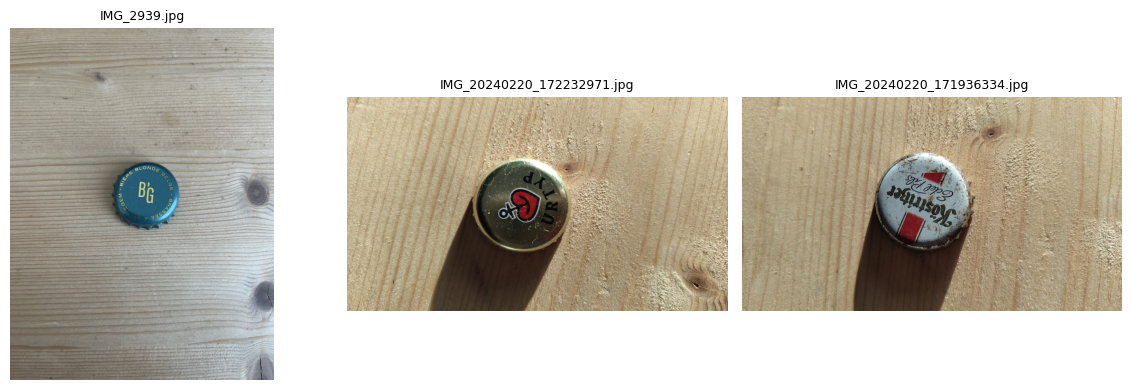

In [92]:
path = "/Users/timothee/Documents/programming/DIHT/data/test_data/IMG_2939.jpg"
fbe._reranker = None
show_images(fbe.find_nearest_neighbors(path, 3))

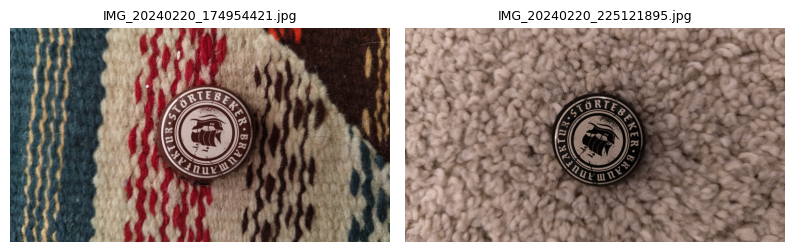

In [ ]:
p = 2
show_images(l[p])

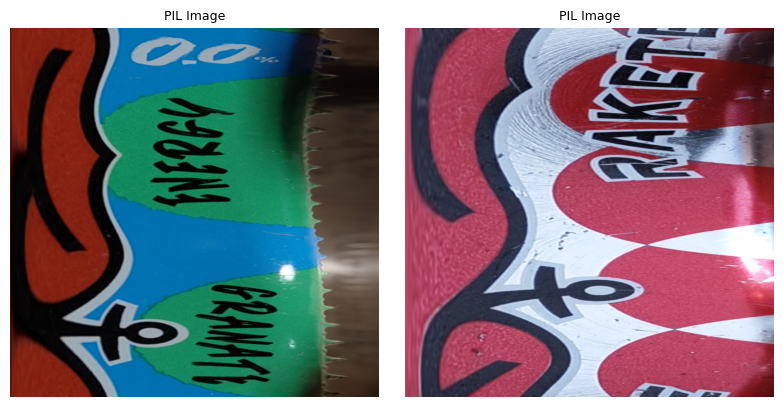

In [ ]:
img_ref = Image.open(l[p][0])
img_comp = Image.open(l[p][1])
show_images([preprocessor(img_ref), preprocessor(img_comp)])

In [84]:
len(fs.get_feature_block(0)[1])

384